<a href="https://colab.research.google.com/github/Adithyasajeev22/EDA-ML-DL-Projects/blob/main/AI_BASED_HEART_ATTACK_PREDICTION_(PROJECT_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT**
 With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

# **EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv('/content/Patients Data ( Used for Heart Disease Prediction ).csv')
df.head(5)

,tientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0.0,1.0,...,Never used e-cigarettes in my entire life,1.0,"White only, Non-Hispanic",0.0,0.0,0.0,1.0,"No, did not receive any tetanus shot in the pa...",0.0,1.0
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0.0,0.0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received Tdap",0.0,0.0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0.0,0.0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",1.0,0.0,0.0,0.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0.0,0.0,...,Never used e-cigarettes in my entire life,0.0,"White only, Non-Hispanic",0.0,0.0,1.0,1.0,"Yes, received tetanus shot but not sure what type",0.0,0.0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0.0,0.0,...,Never used e-cigarettes in my entire life,1.0,"Black only, Non-Hispanic",0.0,0.0,1.0,0.0,"No, did not receive any tetanus shot in the pa...",0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191807 entries, 0 to 191806
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tientID                   191807 non-null  int64  
 1   State                      191807 non-null  object 
 2   Sex                        191807 non-null  object 
 3   GeneralHealth              191807 non-null  object 
 4   AgeCategory                191807 non-null  object 
 5   HeightInMeters             191807 non-null  float64
 6   WeightInKilograms          191807 non-null  float64
 7   BMI                        191807 non-null  float64
 8   HadHeartAttack             191806 non-null  float64
 9   HadAngina                  191806 non-null  float64
 10  HadStroke                  191806 non-null  float64
 11  HadAsthma                  191806 non-null  float64
 12  HadSkinCancer              191806 non-null  float64
 13  HadCOPD                    19

In [ ]:
df.shape

(191807, 35)

In [ ]:
df.columns

Index(['tientID', 'State', 'Sex', 'GeneralHealth', 'AgeCategory',
       'HeightInMeters', 'WeightInKilograms', 'BMI', 'HadHeartAttack',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
tientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,1
HadAngina,1


In [ ]:
df.columns

Index(['tientID', 'State', 'Sex', 'GeneralHealth', 'AgeCategory',
       'HeightInMeters', 'WeightInKilograms', 'BMI', 'HadHeartAttack',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')

In [ ]:
df.dropna(subset=['HadHeartAttack'],inplace=True)
df.dropna(subset=['HadDepressiveDisorder'],inplace=True)
df.dropna(subset=['HadKidneyDisease'],inplace=True)
df.dropna(subset=['HadArthritis'],inplace=True)
df.dropna(subset=['HadDiabetes'],inplace=True)
df.dropna(subset=['DeafOrHardOfHearing'],inplace=True)
df.dropna(subset=['BlindOrVisionDifficulty'],inplace=True)
df.dropna(subset=['DifficultyConcentrating'],inplace=True)
df.dropna(subset=['DifficultyErrands'],inplace=True)
df.dropna(subset=['ChestScan'],inplace=True)
df.dropna(subset=['RaceEthnicityCategory'],inplace=True)
df.dropna(subset=['AlcoholDrinkers'],inplace=True)
df.dropna(subset=['HIVTesting'],inplace=True)
df.dropna(subset=['FluVaxLast12'],inplace=True)
df.dropna(subset=['PneumoVaxEver'],inplace=True)
df.dropna(subset=['TetanusLast10Tdap'],inplace=True)
df.dropna(subset=['HighRiskLastYear'],inplace=True)
df.dropna(subset=['CovidPos'],inplace=True)

In [ ]:
df.dropna(subset=['HadAngina'],inplace=True)

In [ ]:
df.dropna(subset=['HadStroke'],inplace=True)

In [ ]:
df.dropna(subset=['HadAsthma'],inplace=True)

In [ ]:
df.dropna(subset=['HadSkinCancer'],inplace=True)

In [ ]:
df.dropna(subset=['HadCOPD'],inplace=True)

In [ ]:
df.isnull().sum()

,0
tientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.duplicated().sum()

np.int64(4191)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target='HadHeartAttack'

In [ ]:
df[target].value_counts()

,count
HadHeartAttack,
0.0,177004
1.0,10611


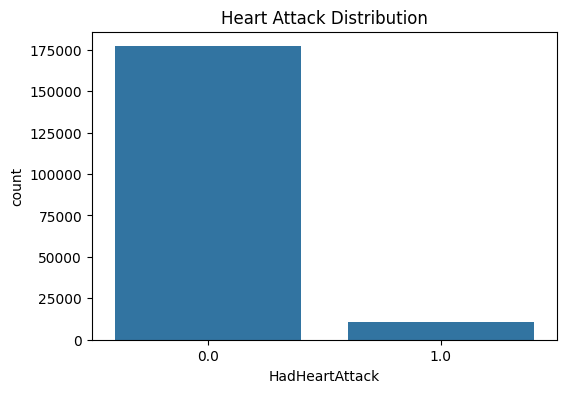

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=target,data=df)
plt.title("Heart Attack Distribution")
plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['State', 'Sex', 'GeneralHealth', 'AgeCategory', 'HadDiabetes',
       'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory',
       'TetanusLast10Tdap'],
      dtype='object')

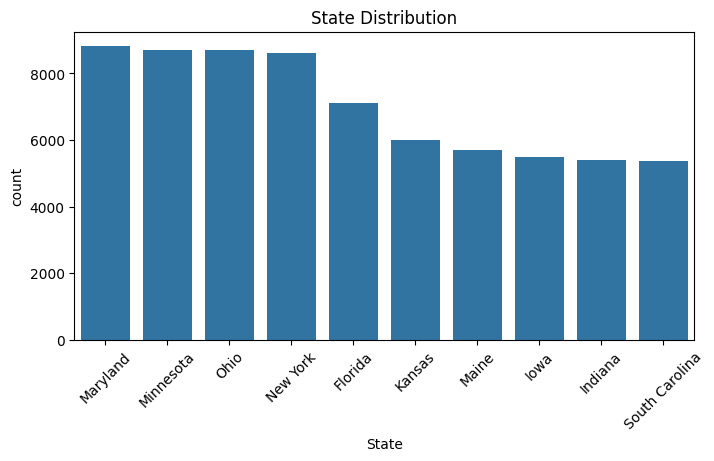

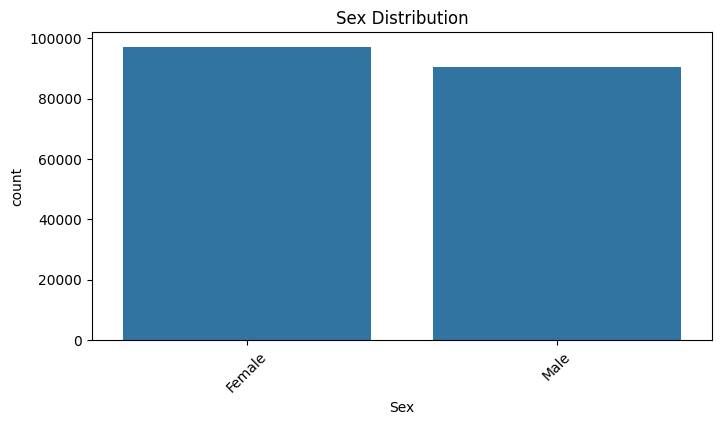

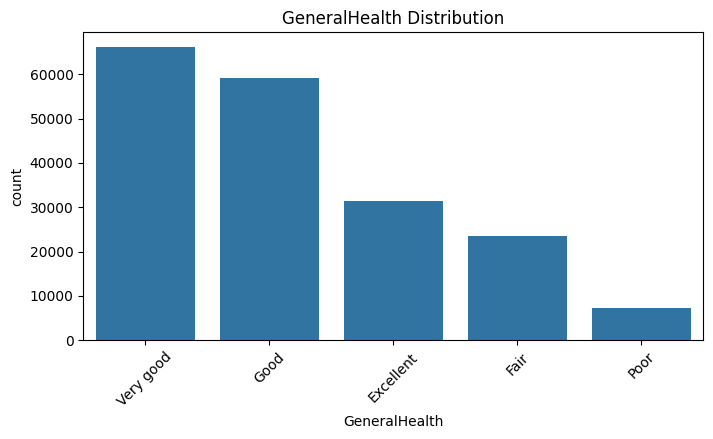

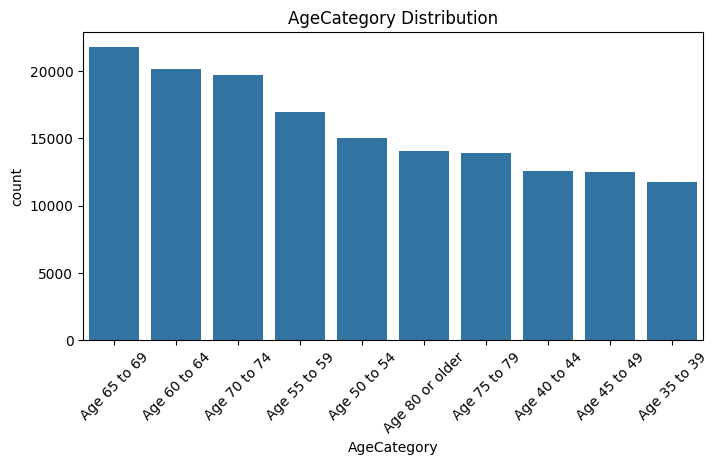

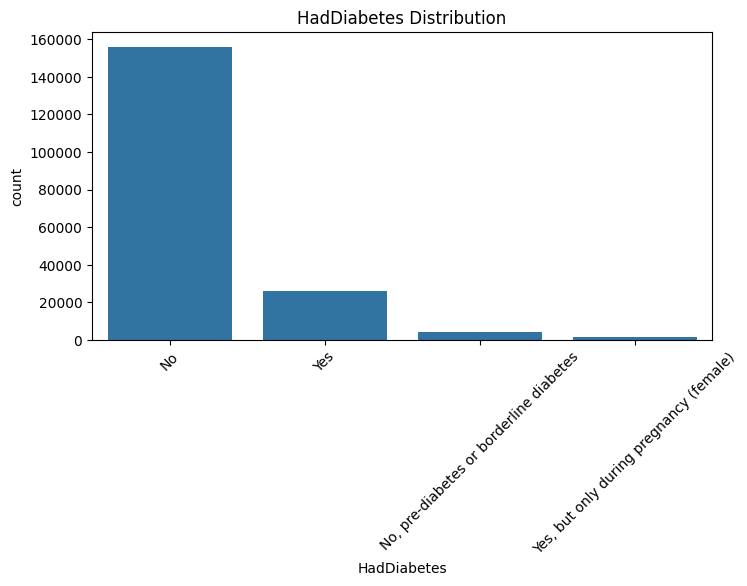

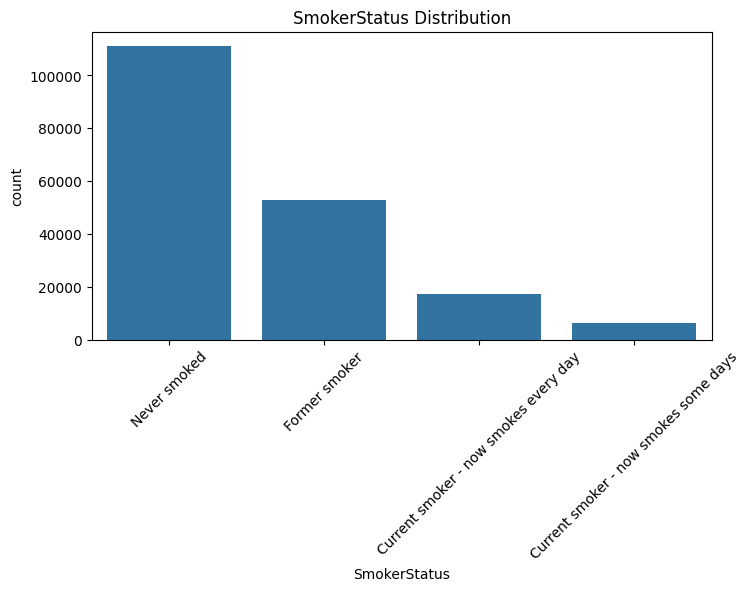

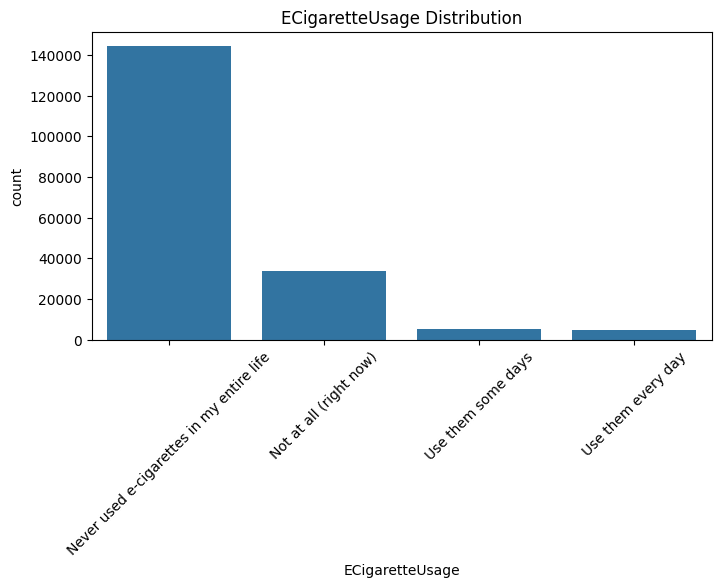

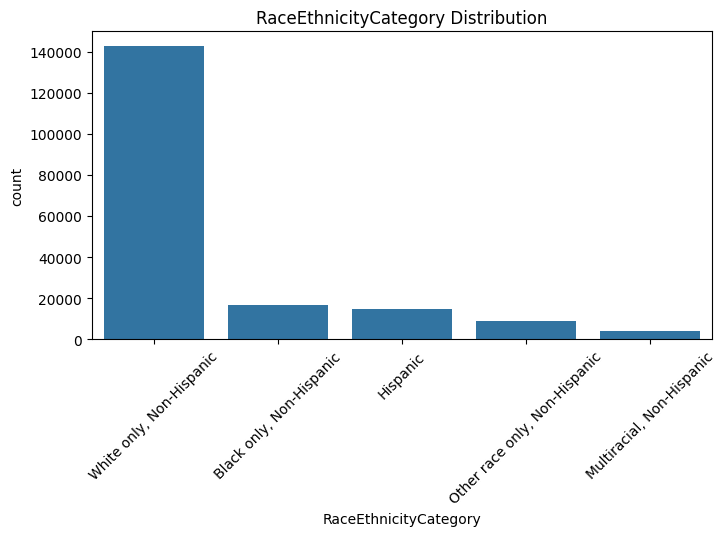

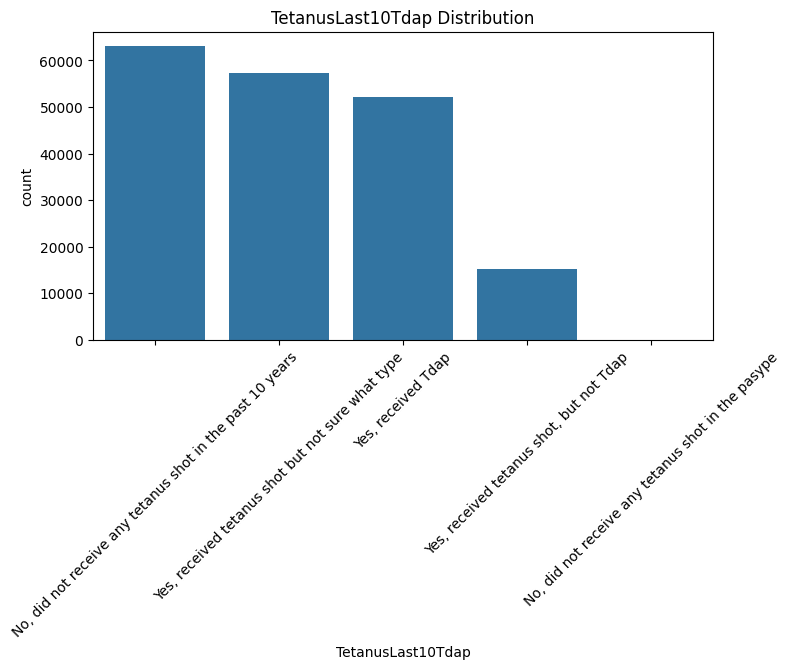

In [ ]:
for col in categorical_cols:
  plt.figure(figsize=(8,4))
  sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
  plt.xticks(rotation=45)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['tientID', 'HeightInMeters', 'WeightInKilograms', 'BMI',
       'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'ChestScan',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'HighRiskLastYear', 'CovidPos'],
      dtype='object')

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


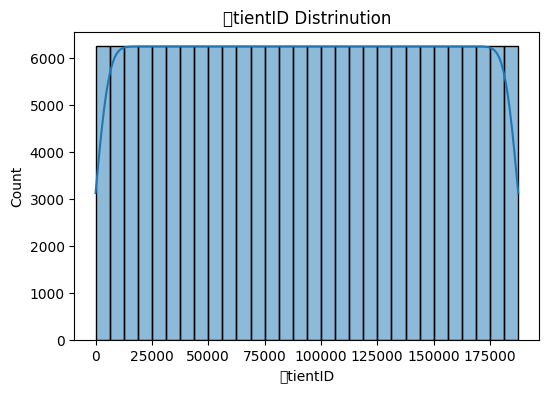

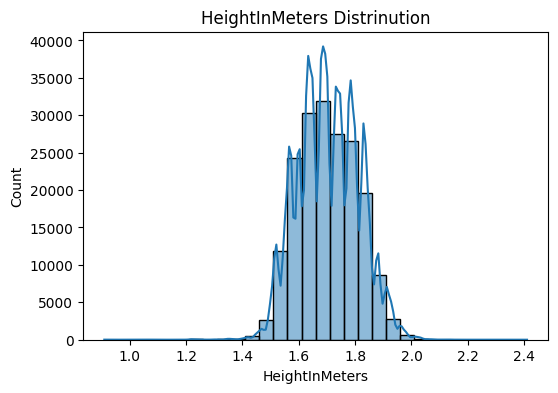

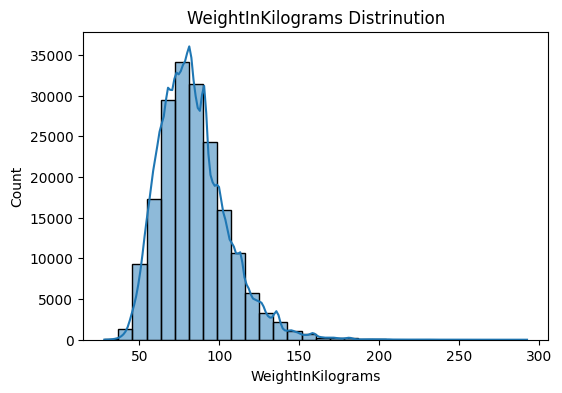

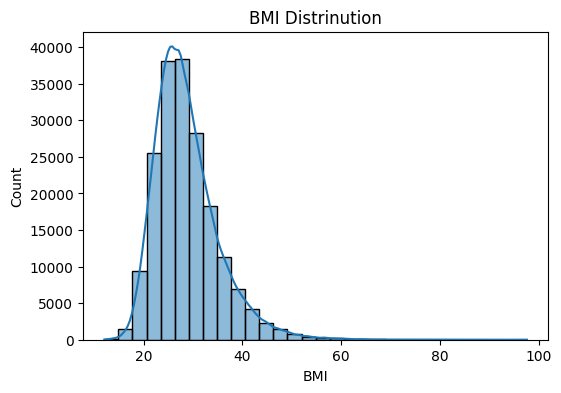

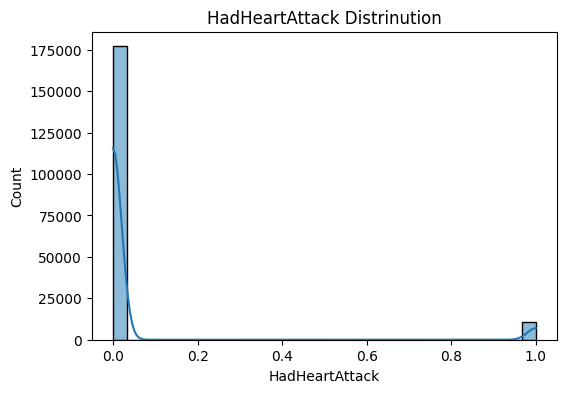

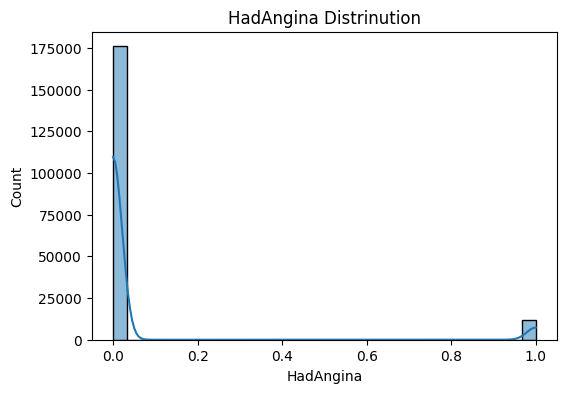

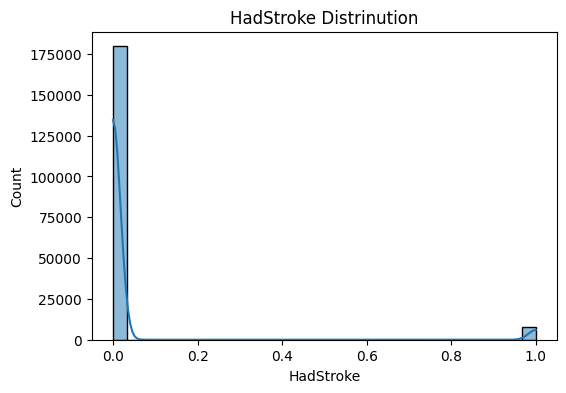

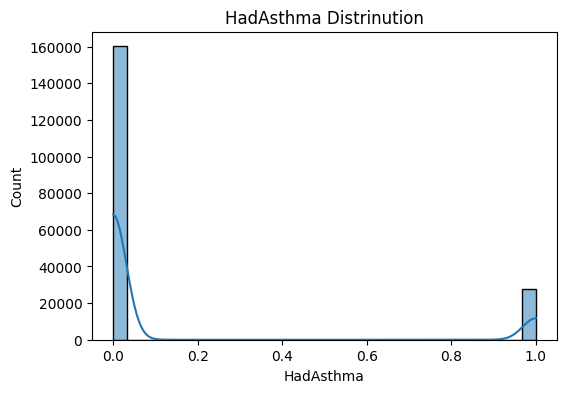

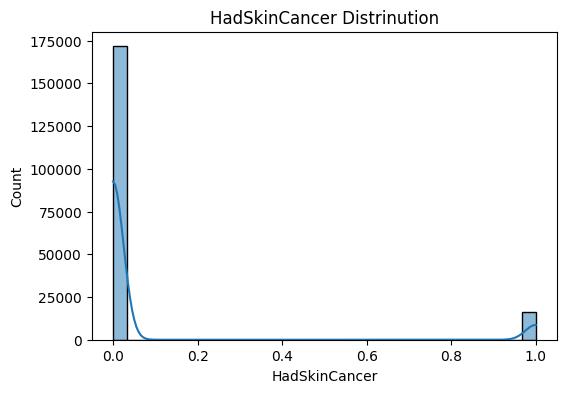

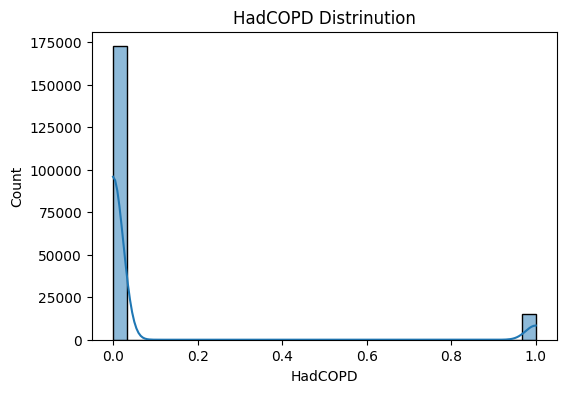

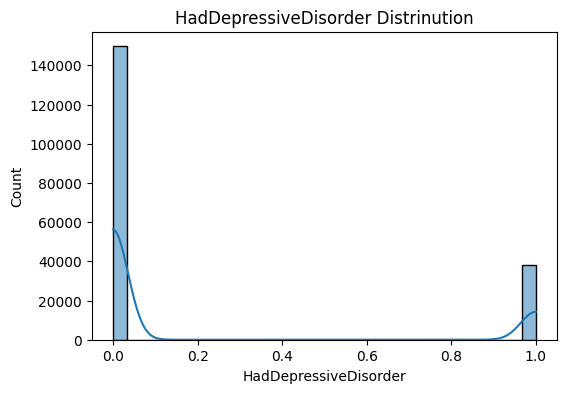

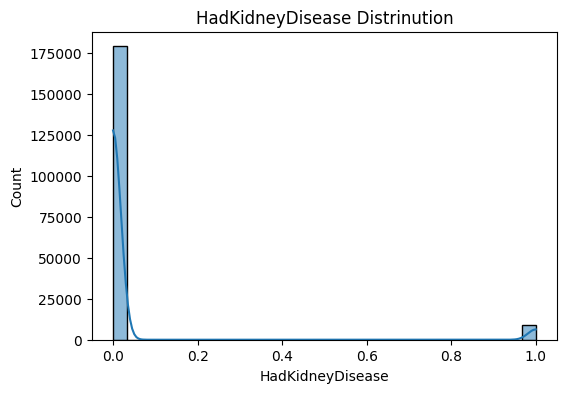

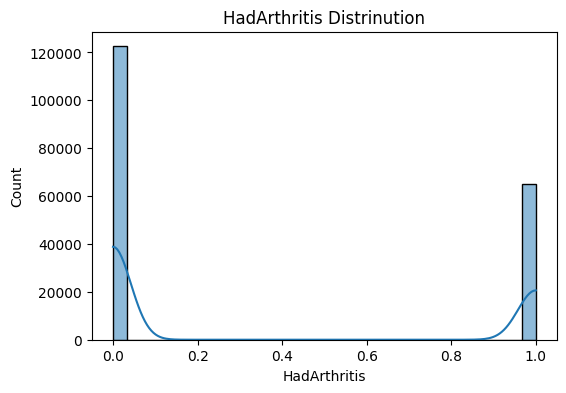

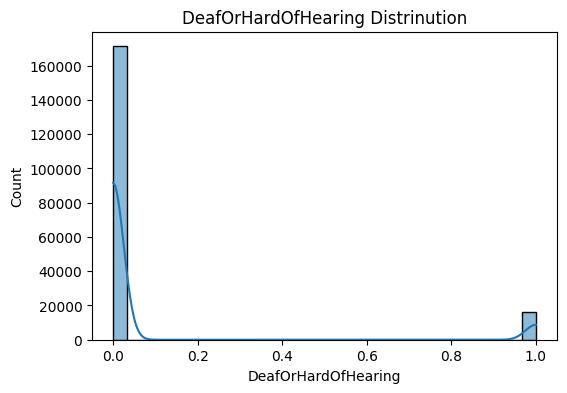

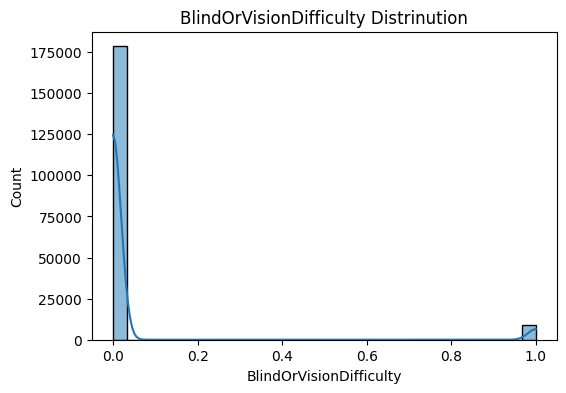

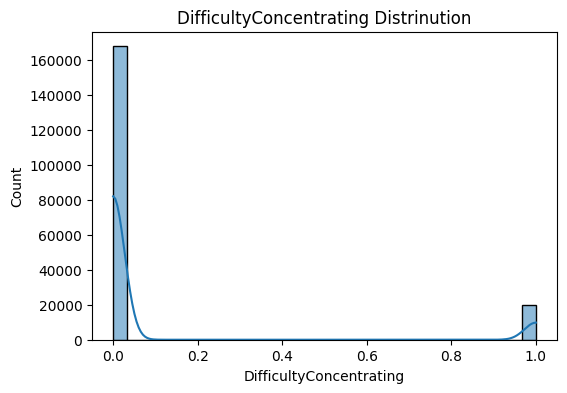

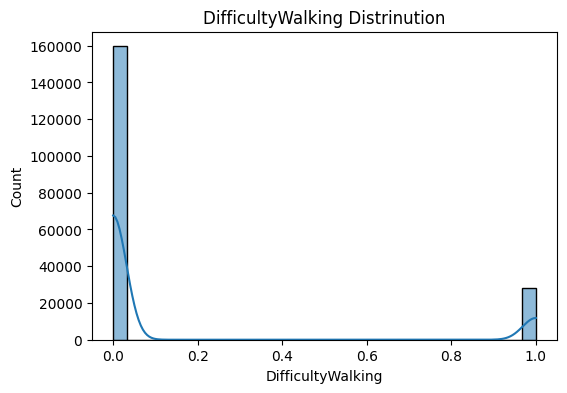

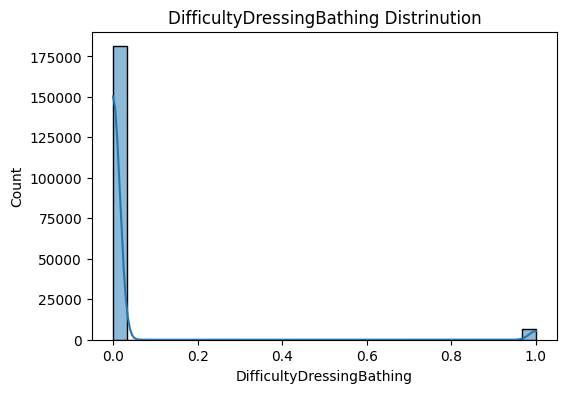

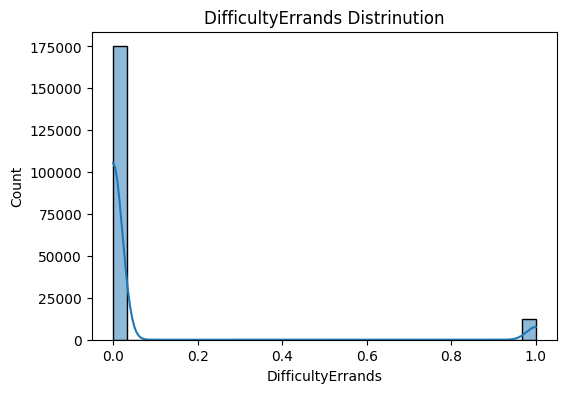

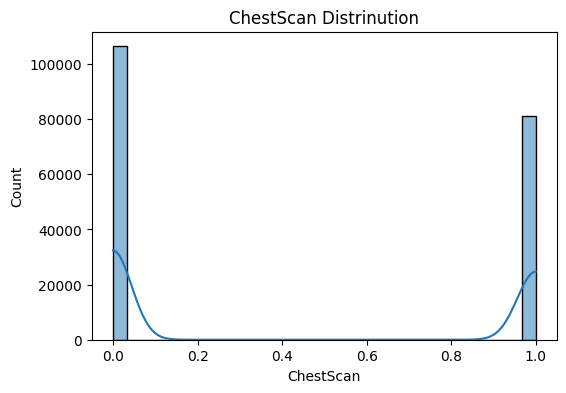

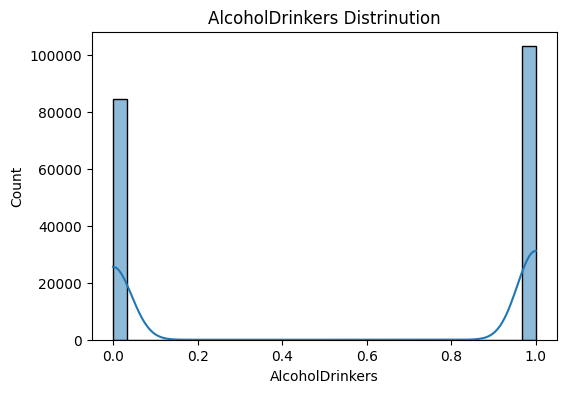

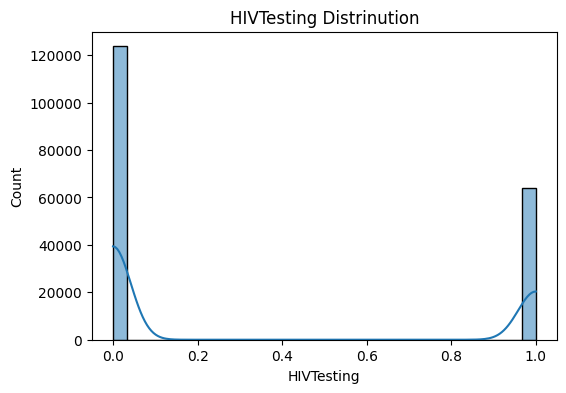

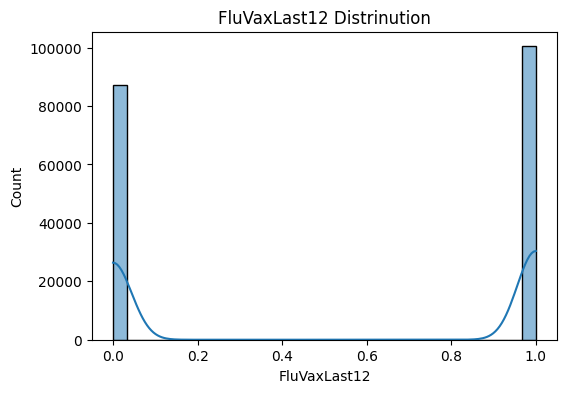

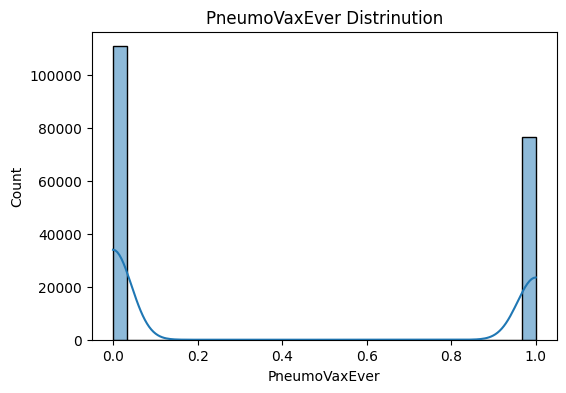

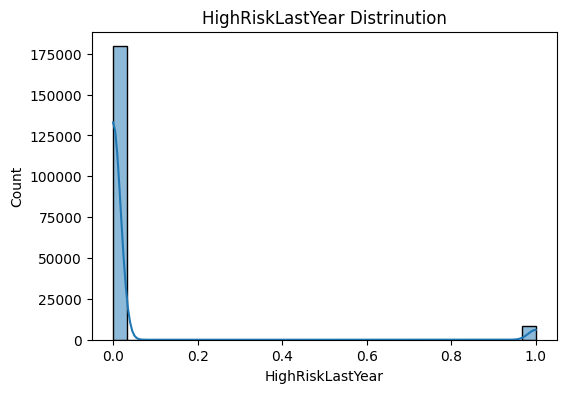

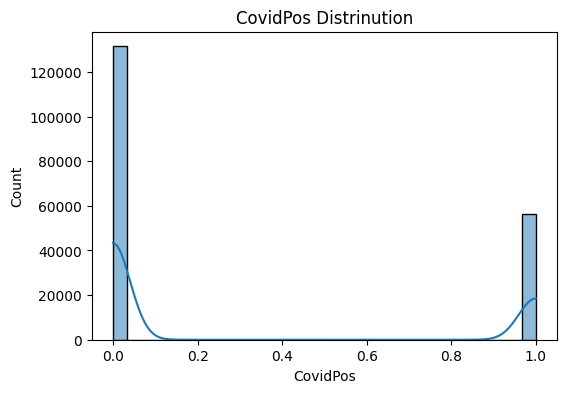

In [ ]:
for col in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],bins=30,kde=True)
  plt.title(f'{col} Distrinution')
  plt.show()

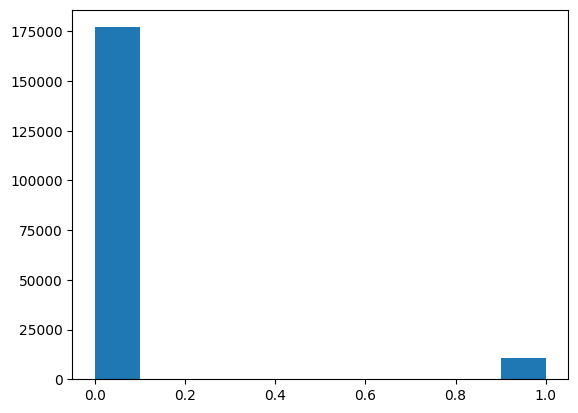

In [ ]:
plt.hist(df['HadHeartAttack'])
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['State']=le.fit_transform(df['State'])
df['Sex']=le.fit_transform(df['Sex'])
df['HadDiabetes']=le.fit_transform(df['HadDiabetes'])
df['SmokerStatus']=le.fit_transform(df['SmokerStatus'])
df['ECigaretteUsage']=le.fit_transform(df['ECigaretteUsage'])
df['RaceEthnicityCategory']=le.fit_transform(df['RaceEthnicityCategory'])

In [ ]:
print(df['GeneralHealth'].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


In [ ]:
print(df['AgeCategory'].unique())

['Age 75 to 79' 'Age 65 to 69' 'Age 60 to 64' 'Age 70 to 74'
 'Age 50 to 54' 'Age 80 or older' 'Age 55 to 59' 'Age 25 to 29'
 'Age 40 to 44' 'Age 30 to 34' 'Age 35 to 39' 'Age 18 to 24'
 'Age 45 to 49']


In [ ]:
print(df['TetanusLast10Tdap'].unique())

['No, did not receive any tetanus shot in the past 10 years'
 'Yes, received Tdap' 'Yes, received tetanus shot but not sure what type'
 'Yes, received tetanus shot, but not Tdap'
 'No, did not receive any tetanus shot in the pasype']


In [ ]:
df['GeneralHealth'].replace(['Fair','Very good','Excellent','Good','Poor'],[0,1,2,3,4],inplace=True)
df['AgeCategory'].replace(['Age 75 to 79','Age 65 to 69','Age 60 to 64','Age 70 to 74','Age 50 to 54','Age 80 or older','Age 55 to 59','Age 25 to 29', 'Age 40 to 44','Age 30 to 34','Age 35 to 39','Age 18 to 24', 'Age 45 to 49'],[0,1,2,3,4,5,6,7,8,9,10,11,12],inplace=True)
df['TetanusLast10Tdap'].replace(['No, did not receive any tetanus shot in the past 10 years','No, did not receive any tetanus shot in the pasype','Yes, received Tdap','Yes, received tetanus shot but not sure what type','Yes, received tetanus shot, but not Tdap'],[0,0,1,2,3],inplace=True)
df['TetanusLast10Tdap'] = df['TetanusLast10Tdap'].astype(float)

/tmp/ipykernel_6244/2330186914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GeneralHealth'].replace(['Fair','Very good','Excellent','Good','Poor'],[0,1,2,3,4],inplace=True)
/tmp/ipykernel_6244/2330186914.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['GeneralHealth'].replace(['Fai

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 187615 entries, 0 to 191805
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   tientID                   187615 non-null  int64  
 1   State                      187615 non-null  int64  
 2   Sex                        187615 non-null  int64  
 3   GeneralHealth              187615 non-null  int64  
 4   AgeCategory                187615 non-null  int64  
 5   HeightInMeters             187615 non-null  float64
 6   WeightInKilograms          187615 non-null  float64
 7   BMI                        187615 non-null  float64
 8   HadHeartAttack             187615 non-null  float64
 9   HadAngina                  187615 non-null  float64
 10  HadStroke                  187615 non-null  float64
 11  HadAsthma                  187615 non-null  float64
 12  HadSkinCancer              187615 non-null  float64
 13  HadCOPD                    187615 

In [ ]:
# Handle missing values in 'CovidPos' before proceeding
# Assuming CovidPos is a categorical/binary column, fill with mode.
df['CovidPos'].fillna(df['CovidPos'].mode()[0], inplace=True)

/tmp/ipykernel_6244/4124947543.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CovidPos'].fillna(df['CovidPos'].mode()[0], inplace=True)


In [ ]:
#SMOTE (OVER SAMPLING) is used to clear inblance

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd



# Features and Target
x = df[['Sex', 'GeneralHealth', 'AgeCategory', 'HeightInMeters', 'BMI',
        'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'HighRiskLastYear', 'CovidPos']]
y = df['HadHeartAttack']

# Apply SMOTE
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

# Combine X and Y into one DataFrame
df_resampled = pd.concat(
    [pd.DataFrame(x_resampled, columns=x.columns),
     pd.DataFrame(y_resampled, columns=['HadHeartAttack'])],
    axis=1
)

# Display balanced dataset
print(df_resampled.head())

# Check class distribution
print(df_resampled['HadHeartAttack'].value_counts())

   Sex  GeneralHealth  AgeCategory  HeightInMeters        BMI  HadAngina  \
0    0              0            0            1.63  32.099998        1.0   
1    0              1            1            1.60  27.990000        0.0   
2    1              2            2            1.78  22.530001        0.0   
3    1              1            3            1.78  30.129999        0.0   
4    0              3            4            1.68  27.760000        0.0   

   HadStroke  HadAsthma  HadSkinCancer  HadCOPD  ...  ECigaretteUsage  \
0        0.0        1.0            1.0      0.0  ...                0   
1        0.0        0.0            0.0      0.0  ...                0   
2        0.0        0.0            0.0      0.0  ...                0   
3        0.0        0.0            0.0      0.0  ...                0   
4        0.0        0.0            0.0      0.0  ...                0   

   ChestScan  RaceEthnicityCategory  AlcoholDrinkers  HIVTesting  \
0        1.0                      4 

In [ ]:
df=df_resampled

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354008 entries, 0 to 354007
Data columns (total 31 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Sex                        354008 non-null  int64  
 1   GeneralHealth              354008 non-null  int64  
 2   AgeCategory                354008 non-null  int64  
 3   HeightInMeters             354008 non-null  float64
 4   BMI                        354008 non-null  float64
 5   HadAngina                  354008 non-null  float64
 6   HadStroke                  354008 non-null  float64
 7   HadAsthma                  354008 non-null  float64
 8   HadSkinCancer              354008 non-null  float64
 9   HadCOPD                    354008 non-null  float64
 10  HadDepressiveDisorder      354008 non-null  float64
 11  HadKidneyDisease           354008 non-null  float64
 12  HadArthritis               354008 non-null  float64
 13  HadDiabetes                35

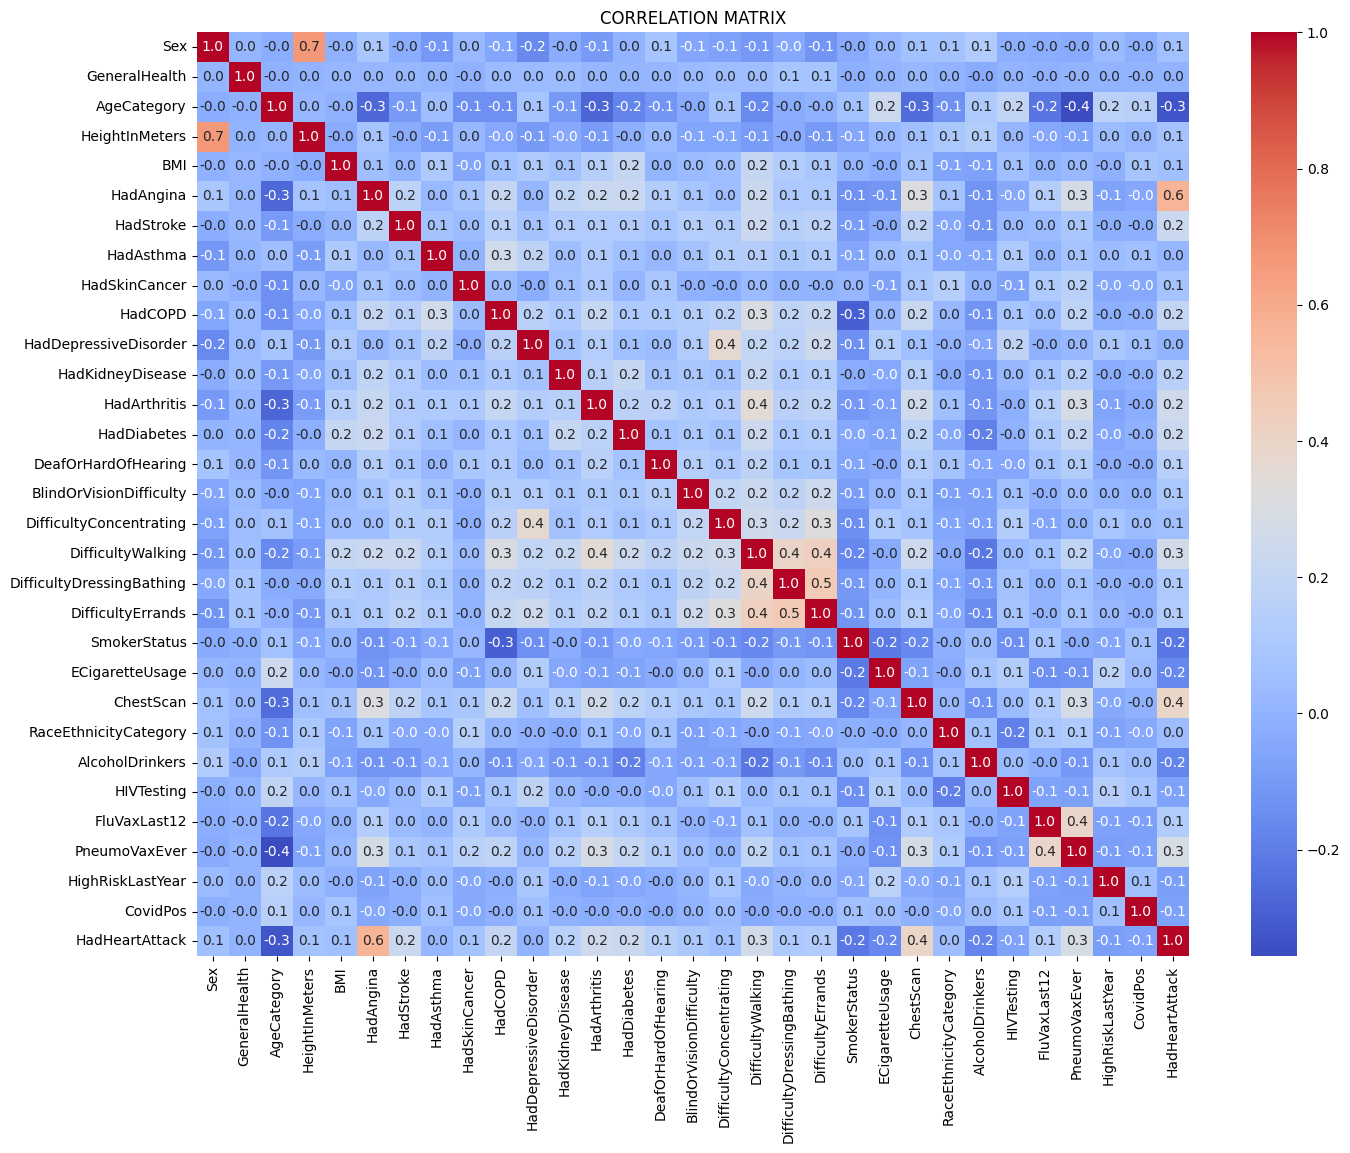

In [ ]:
corr_matrix=df.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('CORRELATION MATRIX')
plt.show()

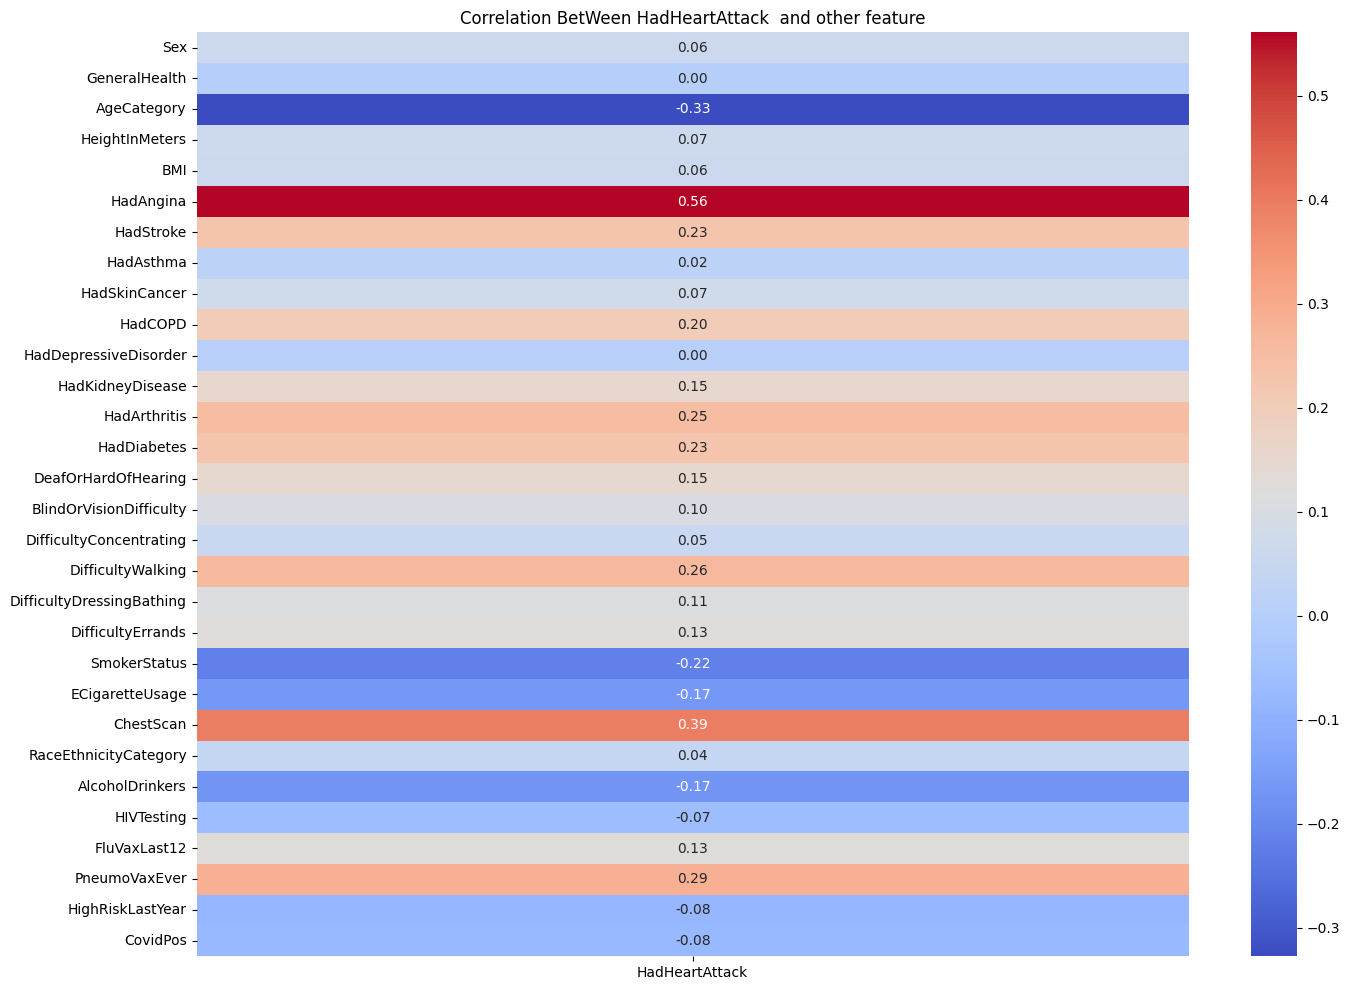

In [ ]:
status_corr=df.corr()['HadHeartAttack']
status_corr=status_corr.drop('HadHeartAttack')
plt.figure(figsize=(16,12))
sns.heatmap(status_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation BetWeen HadHeartAttack  and other feature')
plt.show()

In [ ]:
df.columns

Index(['Sex', 'GeneralHealth', 'AgeCategory', 'HeightInMeters', 'BMI',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'HighRiskLastYear', 'CovidPos', 'HadHeartAttack'],
      dtype='object')

In [ ]:
df.shape

(354008, 31)

<Axes: >

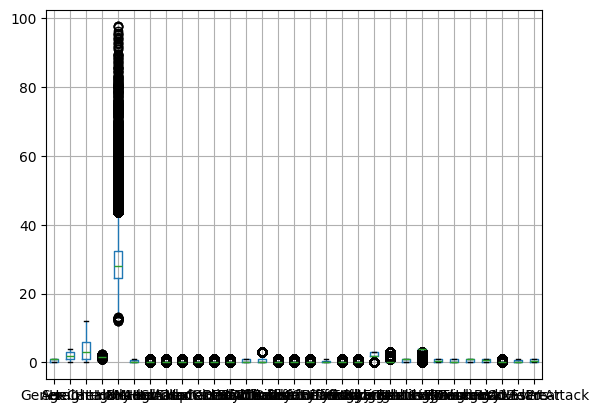

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr

    df=df[(df[col] >=lower_bound)& (df[col] <=upper_bound)]
  return df

df_cleaned=remove_outliers_iqr(df,exclude_column='HadHeartAttack')
df=df_cleaned

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43814 entries, 1 to 353981
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sex                        43814 non-null  int64  
 1   GeneralHealth              43814 non-null  int64  
 2   AgeCategory                43814 non-null  int64  
 3   HeightInMeters             43814 non-null  float64
 4   BMI                        43814 non-null  float64
 5   HadAngina                  43814 non-null  float64
 6   HadStroke                  43814 non-null  float64
 7   HadAsthma                  43814 non-null  float64
 8   HadSkinCancer              43814 non-null  float64
 9   HadCOPD                    43814 non-null  float64
 10  HadDepressiveDisorder      43814 non-null  float64
 11  HadKidneyDisease           43814 non-null  float64
 12  HadArthritis               43814 non-null  float64
 13  HadDiabetes                43814 non-null  int64  

In [ ]:
df.columns

Index(['Sex', 'GeneralHealth', 'AgeCategory', 'HeightInMeters', 'BMI',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'HighRiskLastYear', 'CovidPos', 'HadHeartAttack'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['Sex', 'GeneralHealth', 'AgeCategory', 'HeightInMeters', 'BMI',
       'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'HighRiskLastYear', 'CovidPos']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

# **MACHINE LEARNING**

In [ ]:
# LOGISTIC REGRESSION

x=df[['Sex', 'GeneralHealth', 'AgeCategory', 'HeightInMeters', 'BMI',
        'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'HighRiskLastYear', 'CovidPos']]
y=df['HadHeartAttack']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline Model Accuracy:{accuracy:.2f}')

Baseline Model Accuracy:0.84


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# DECISION TREE

from sklearn.tree import DecisionTreeClassifier

x=df[['Sex', 'GeneralHealth', 'AgeCategory', 'HeightInMeters', 'BMI',
        'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'HighRiskLastYear', 'CovidPos']]
y=df['HadHeartAttack']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline Model Accuracy:{accuracy:.2f}')

Baseline Model Accuracy:0.96


In [ ]:
# SVC
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# pipeline
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Pipeline Linear SVC Accuracy: {accuracy:.2f}")

Pipeline Linear SVC Accuracy: 0.84


In [ ]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:0.98


In [ ]:
# GRADIENTBOOSTER

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9551761913456271


In [ ]:
# ADA BOOST

from sklearn.ensemble import AdaBoostClassifier

model=AdaBoostClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.93


In [ ]:
# XGBOOST

from  xgboost import XGBClassifier

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=XGBClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.97


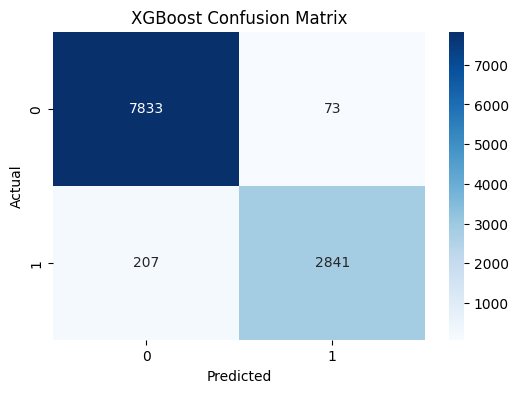

In [ ]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

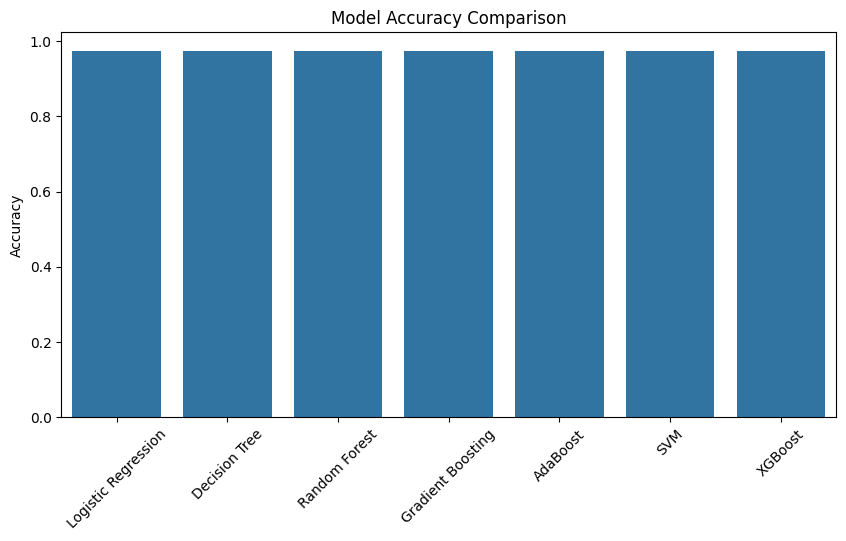

In [ ]:
models=[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost',
    'SVM',
    'XGBoost']

accuracies=[
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred),
    accuracy_score(y_test,y_pred)]

plt.figure(figsize=(10,5))

sns.barplot(x=models,y=accuracies)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# **K-FOLD CROSS VALIDATION**

In [ ]:
x=df.drop('HadHeartAttack',axis=1)
y=df['HadHeartAttack']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression(max_iter=10000)

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):

    print(f"\nFold {fold}")

    x_train,x_test=x.iloc[train_index],x.iloc[test_index]
    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(x_train,y_train)

    y_pred=model.predict(x_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc
        best_fold=fold

        best_x_train=x_train
        best_y_train=y_train

        best_x_test=x_test
        best_y_test=y_test

        best_y_pred=y_pred

print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Fold 1
Accuracy: 0.84423142759329

Fold 2
Accuracy: 0.8419491041880635

Fold 3
Accuracy: 0.8476549127011298

Fold 4
Accuracy: 0.8478831450416524

Fold 5
Accuracy: 0.8486646884272997

Best Fold: 5 with Accuracy: 0.8486646884272997


In [ ]:
model=LogisticRegression(max_iter=10000)
model.fit(best_x_train,best_y_train)
print("Logistic Regression:",model.score(best_x_test,best_y_test))

Logistic Regression: 0.8486646884272997


In [ ]:
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
print("Random Forest:",model.score(best_x_test,best_y_test))

Random Forest: 0.975348094042456


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(best_x_train,best_y_train)
print("Decision Tree:",model.score(best_x_test,best_y_test))

Decision Tree: 0.9537776763296051


In [ ]:
model=SVC()
model.fit(best_x_train,best_y_train)
print("SVM:",model.score(best_x_test,best_y_test))

SVM: 0.8415886783839306


In [ ]:
model=GradientBoostingClassifier(random_state=42)
model.fit(best_x_train,best_y_train)
print("Gradient Boosting:",model.score(best_x_test,best_y_test))

Gradient Boosting: 0.9517233508331431


In [ ]:
model=AdaBoostClassifier(random_state=42)
model.fit(best_x_train,best_y_train)
print("AdaBoost:",model.score(best_x_test,best_y_test))

AdaBoost: 0.9295822871490528


In [ ]:
model=XGBClassifier(eval_metric='logloss',random_state=42)
model.fit(best_x_train,best_y_train)
print("XGBoost:",model.score(best_x_test,best_y_test))

XGBoost: 0.9739785437114814


# **DEEP LEARNING**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


model=Sequential()
model.add(Dense(120,input_shape=(x.shape[1],),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

model.fit(best_x_train,best_y_train,epochs=150)

y_pred=model.predict(best_x_test)
y_pred=(y_pred>0.5).astype(int)

print(f'\nAccuracy: {accuracy_score(best_y_test,y_pred)}')

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1096/1096 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8215 - loss: 0.4075
Epoch 2/150
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8481 - loss: 0.3630
Epoch 3/150
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8537 - loss: 0.3508
Epoch 4/150
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8565 - loss: 0.3469
Epoch 5/150
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8602 - loss: 0.3415
Epoch 6/150
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8595 - loss: 0.3377
Epoch 7/150
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8614 - loss: 0.3322
Epoch 8/150
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8641 - loss: 0.3287
Epoch 9/150
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8646 - loss: 0.3232
Epoch 10/150
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8672 - loss: 0.3186
Epoch 11/150
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8706 - loss: 0.3118
Epoch 12/150
1096/1096 ━━━━━━━━

# **CONCLUSION**



The AI-Based Student Performance Prediction System was developed to predict student academic performance using machine learning and deep learning techniques. Several models were evaluated, and the Random Forest Classifier achieved the highest accuracy of 97.53%, making it the best-performing model. The results demonstrate that factors such as attendance, assessment marks, study hours, and previous academic performance significantly influence student outcomes. This system can help educational institutions identify students who may need additional support and enable timely interventions to improve academic success. Overall, the project highlights the effectiveness of artificial intelligence in enhancing educational decision-making and student performance management.


# **FUTURE SCOPE**



In the future, this system can be improved by incorporating real-time student data such as attendance, assignments, and examination scores. Advanced machine learning and deep learning techniques can be explored to further enhance prediction accuracy. The model can also be integrated into web or mobile applications for easier access by students and educators. Additionally, personalized recommendations can be provided to help students improve their academic performance. These enhancements can make the system more effective and practical for educational institutions.
